# Comparación del parámetro `chunk_size` en `TravelTimeMatrices`

El siguiente _notebook_ es una comparación del parámetro `chunk_size` en
`TravelTimeMatrices.compute()`, observando el cambio en el tiempo de
computación al variar el parámetro, y sirviendo como evidencia para escoger un
valor por defecto para el mismo.

Se utilizará el área urbana de Puerto Montt para obtener los orígenes; los
destinos serán farmacias dentro de la envoltura convexa.

In [ ]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

import datetime
from time import time
from pathlib import Path

In [ ]:
import xmin
from xmin.dataset import extract_osm_subset

In [ ]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [ ]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
OSM_PUERTOMONTT_PATH = PRE_DATA_PATH / "osm" / "Puerto_Montt.osm.pbf"

## Orígenes y destinos

In [ ]:
# carga de datos y cambio de sistema de coordenadas
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24"
)
limites_urbanos = limites_urbanos_full.to_crs(4326)

# filtramos solo las áreas de interés
limites_urbanos = limites_urbanos[
    (limites_urbanos["COMUNA"] == "PUERTO MONTT")
]

# obtenemos envoltura convexa para extraer POIs y red vial
limites_envoltura = limites_urbanos.union_all().convex_hull

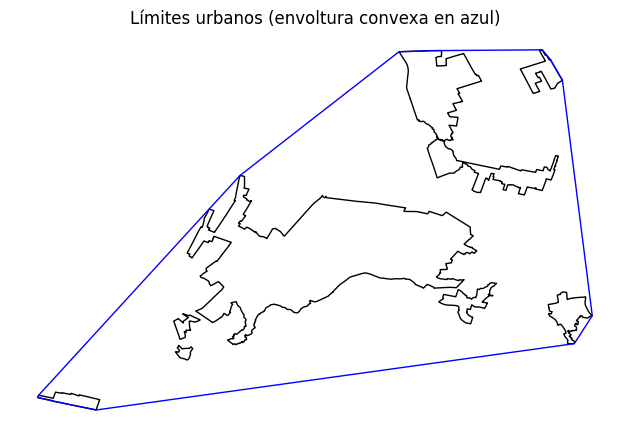

In [ ]:
ax = limites_urbanos.plot(facecolor="none", edgecolor="black")
gpd.GeoSeries([limites_envoltura]).plot(
    ax=ax, facecolor="none", edgecolor="blue"
)
ax.set_axis_off()
plt.title("Límites urbanos (envoltura convexa en azul)")
plt.tight_layout()

In [ ]:
origins = xmin.Origins.create_grid(
    regions=limites_urbanos,
    h3_resolution=10,
)
len(origins.h3_grid)

3863

In [ ]:
if not OSM_PUERTOMONTT_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_PUERTOMONTT_PATH,
        bounds=limites_envoltura
    )

In [ ]:
farmacias = xmin.Amenity.from_osm(
    name="farmacias",
    osm_path=OSM_PUERTOMONTT_PATH,
    osm_filter={"amenity": ["pharmacy"]},
)

## Cálculo de TTMs

Calcularemos las matrices de tiempo de viaje con distintos valores de
`chunk_size`. Para cada valor, repetiremos el cálculo 5 veces para ver la
varianza en el tiempo de computación.

In [ ]:
N = 5
chunk_sizes = [1, 3, 10, 30, 100, 300, 1_000, None]
times = {key: [] for key in chunk_sizes}
ttms_per_chunk_size = {}

for chunk_size in times.keys():
    print(f"CHUNK SIZE: {chunk_size}")
    for _ in range(N):
        t0 = time()
        ttms = xmin.TravelTimeMatrices.compute(
            origins=origins,
            amenities=[farmacias],
            gtfs_paths=[],
            osm_path=OSM_PUERTOMONTT_PATH,
            snap_to_network=True,
            max_time=datetime.timedelta(minutes=30),
            transport_modes=["WALK"],
            chunk_size=chunk_size
        )
        t1 = time()
        times[chunk_size].append(t1 - t0)
    ttms_per_chunk_size[chunk_size] = ttms

In [ ]:
times[len(origins.h3_grid)] = times.pop(None)

In [ ]:
# verificamos que todas las matrices sean iguales
traveltime_dfs = [
    ttms.matrices["farmacias"] for _, ttms in ttms_per_chunk_size.items()
]
all(df.equals(traveltime_dfs[0]) for df in traveltime_dfs)

True

## Comparación

In [ ]:
times_df = pd.DataFrame(times)
times_recap = times_df.agg(["mean", "std"]).T

In [ ]:
times_recap

,mean,std
1,51.345736,0.773454
3,33.269278,2.081954
10,25.256800,0.336773
30,25.053513,0.594795
100,26.722284,1.122528
300,27.364607,1.419853
1000,27.420709,1.450203
3863,27.811991,0.556868


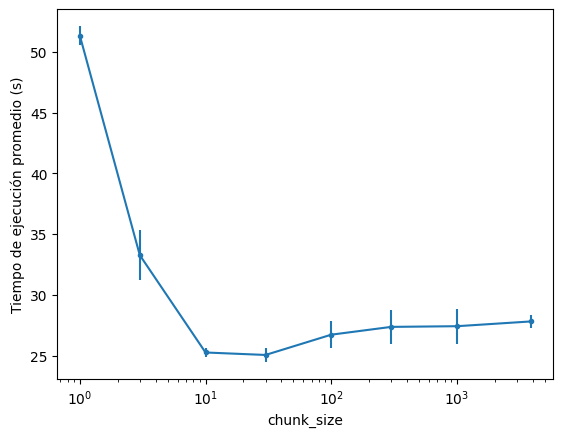

In [ ]:
plt.errorbar(
    times_recap.index, times_recap["mean"], yerr=times_recap["std"], marker="."
)
plt.xscale("log")
plt.xlabel("chunk_size")
plt.ylabel("Tiempo de ejecución promedio (s)")
plt.show()

Se puede observar que, descartando los `chunk_size` muy pequeños (1 y 3), los
tiempos de ejecución son bastante estables respecto al tamaño de los *chunks*.
No es necesario tener un `chunk_size` muy elevado para que el costo asociado a
la reinicialización de `r5py.TravelTimeMatrix()` sea marginal; incluso se
observan mejores tiempos para `chunk_size` entre 10 y 100 (aunque, considerando
los rangos de desviación estándar, la diferencia no es notoria).

Debido a lo anterior, se decidió utilizar `chunk_size=32` como valor por
defecto, ya que es lo suficientemente grande como para ser eficiente, y lo
suficientemente pequeño como para mostrar un crecimiento granular de la barra
de progreso.